<br>
<div align="center">

<small>I206 · Inferencia y Estimación</small>

# **Trabajo Práctico II**
## Teoría de la Información
<small>***Codificación de Huffman***</small>

<br>
</div>

---
#### **Imports y Variables Globales**

---

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from collections import OrderedDict
import unicodedata # para el análisis sin diacríticos y detectar puntuación

# Algoritmo Huffman provisto por la catedra
from huffman_code import huffman_code

filepath = Path('text_examples') 
figures_path = '../report/figures/'

# Creacion de vectores con: Nombre de Texto - Textos, ambos provistos por la catedra  
example_strings_name = []
example_strings = []

for file in filepath.glob('*.txt'):
    example_strings_name.append(file.name)
    with file.open('r', encoding='utf-8') as f:
        example_strings.append(f.read())

---

### **EJERCICIO 1:** Masa de Probabilidad de Caracteres

---

In [55]:
def character_pmf(txt: str, ignore: bool = False) -> OrderedDict[str, float]:
	""" 
	Dado una cadena de texto devuelve un diccionario representando la masa de probabilidad de cada caracter en la cadena

	Args:
		txt (str): cadena de texto
		ignore_diacritical (bool): indica si es requerido tomar a todos los caracteres con diacríticos como el mismo

	Returns:
		OrderedDict[str, float]: diccionario ordenado en funcion de la frecuencia de aparicion {caracter : frecuencia}

	Note: 
		- Convierte todas las letras a minusculas con el metodo '.lower()'
		- El metodo '.strip()' ignora los espacios iniciales y finales
		- ignore_diacritical == True entonces a = à, á, â, ä, ...
	"""
	txt = txt.lower()
	n = len(txt)
	pmf = OrderedDict()

	if ignore:
		txt = ''.join(c for c in unicodedata.normalize('NFD', txt) if unicodedata.category(c) != 'Mn' and (c.isalnum() or c.isspace()))

	for c in txt:
		if c: pmf[c] = pmf.get(c, 0.0) + 1/n 
	return pmf

def pmf_chart(pmf : OrderedDict[str, float], 
              fig: plt.Figure = None, 
              subplot_idx: int = None, 
              color: str = None, 
              file_name: str = None) -> None:
    
    """ 
    A partir de la masa de probabilidad estimada para los caracteres de un string, realiza un gráfico de barras con la frecuencia de cada caracter en ordern descendente según la frecuencia.
    
    Args:
        pmf (OrderedDict[str, float]): diccionario ordenado en funcion de la frecuencia de aparicion {caracter : frecuencia}
        fig (plt.figure.Figure): objeto figura de matplotlib en donde se creará el subplot
        subplot_idx (int): entero de 3 dígitos que representa el índice del subplot a agregar ('row' 'collumn' 'index')
        color (str): color de las barras del gráfico
        file_name (str): nombre del archivo de texto analizado para colocar como título del gráfico

    Note: 
        - Si no se provee idx, y color, se asignan valores 111, y 'b' respectivamente.
    
    """ 

    # Ordena por frecuencia descendente segun la probabilidad de cada caracter
    pmf = OrderedDict(sorted(pmf.items(), key=lambda x: x[1], reverse=True)) 
    
    # Asigno valores en caso de None
    if fig is None: fig = plt.figure(figsize=(10,6))
    if subplot_idx is None: subplot_idx = 111
    if color is None: color = 'b'
    
    # Creo subplot
    ax = fig.add_subplot(subplot_idx)

    # Grafico los datos
    ax.bar(pmf.keys(), pmf.values(), color=color, edgecolor='black')
    
    # Apartado de Estetica
    if file_name is not None:
        ax.set_title(file_name, fontsize=22)
    ax.set_ylabel('frequency', fontsize=16)
    ax.tick_params(axis='both', which='both', labelsize=20)
    ax.grid(axis='y')

**Resultado para los textos de ejemplo**

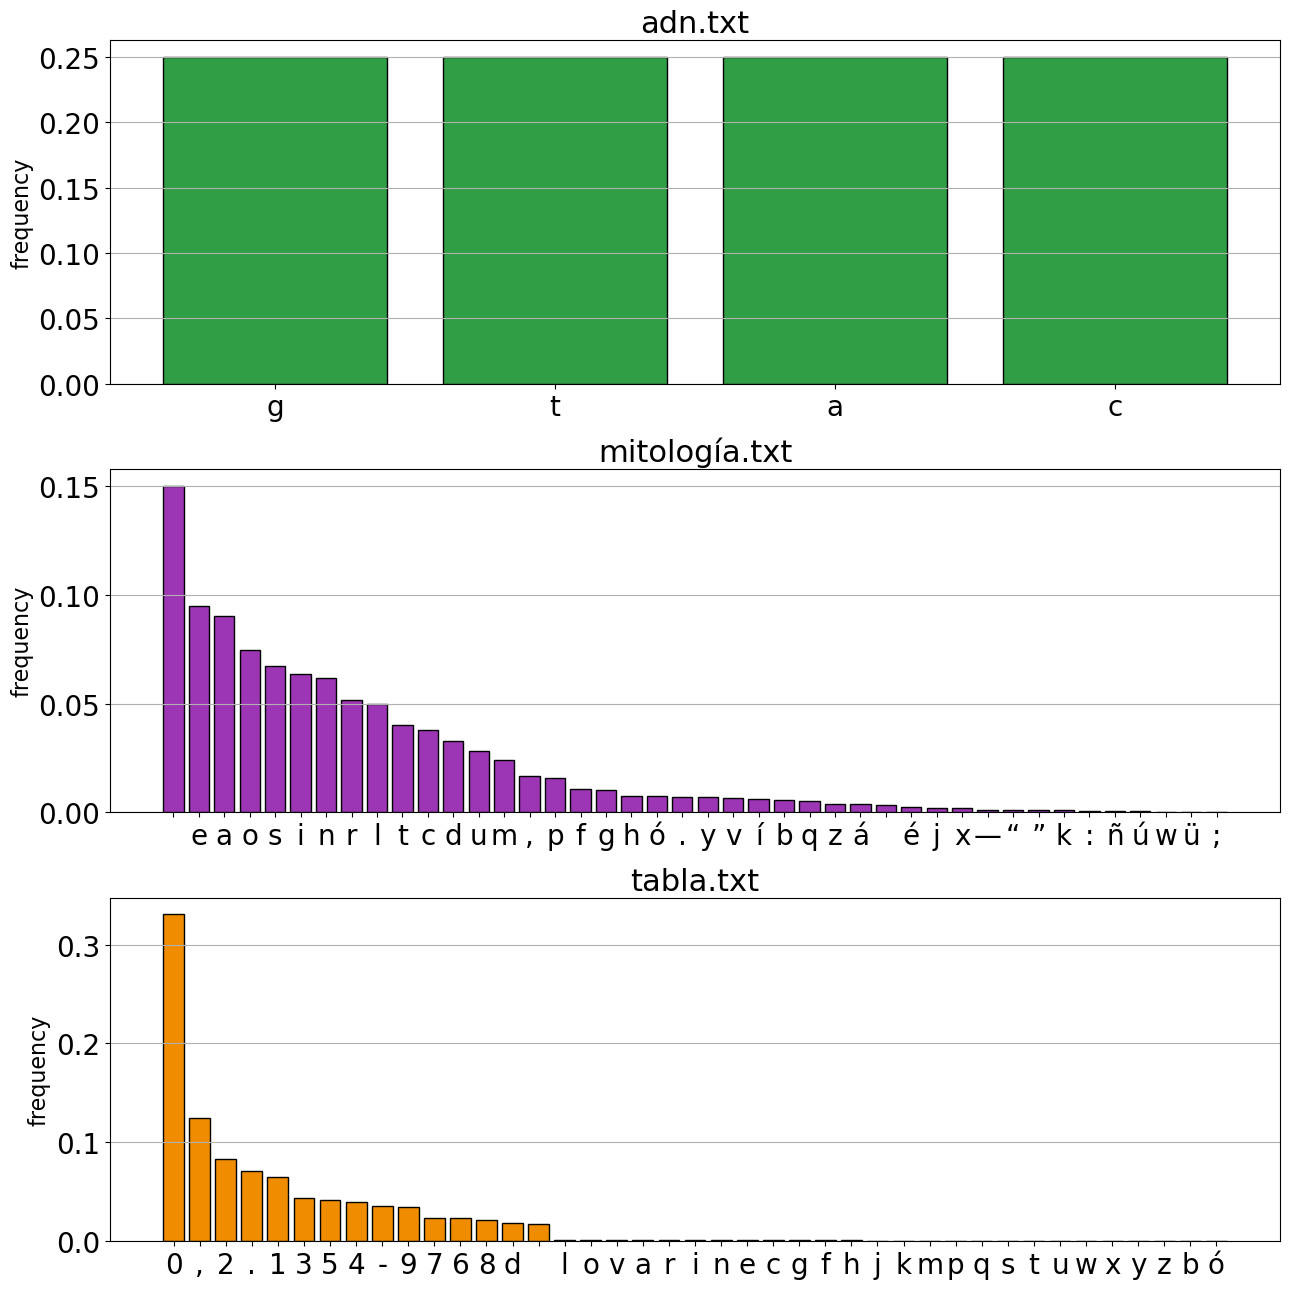

In [56]:
fig = plt.figure(figsize=(13,13))
idx = 311
colors = ['#f08c00', '#9c36b5', '#2f9e44']

for file, string in zip(example_strings_name, example_strings):
    pmf = character_pmf(string)
    pmf_chart(pmf, fig, idx, colors.pop(), file)
    idx += 1

plt.tight_layout()
plt.savefig(figures_path + 'character_pmf.png')
plt.show()

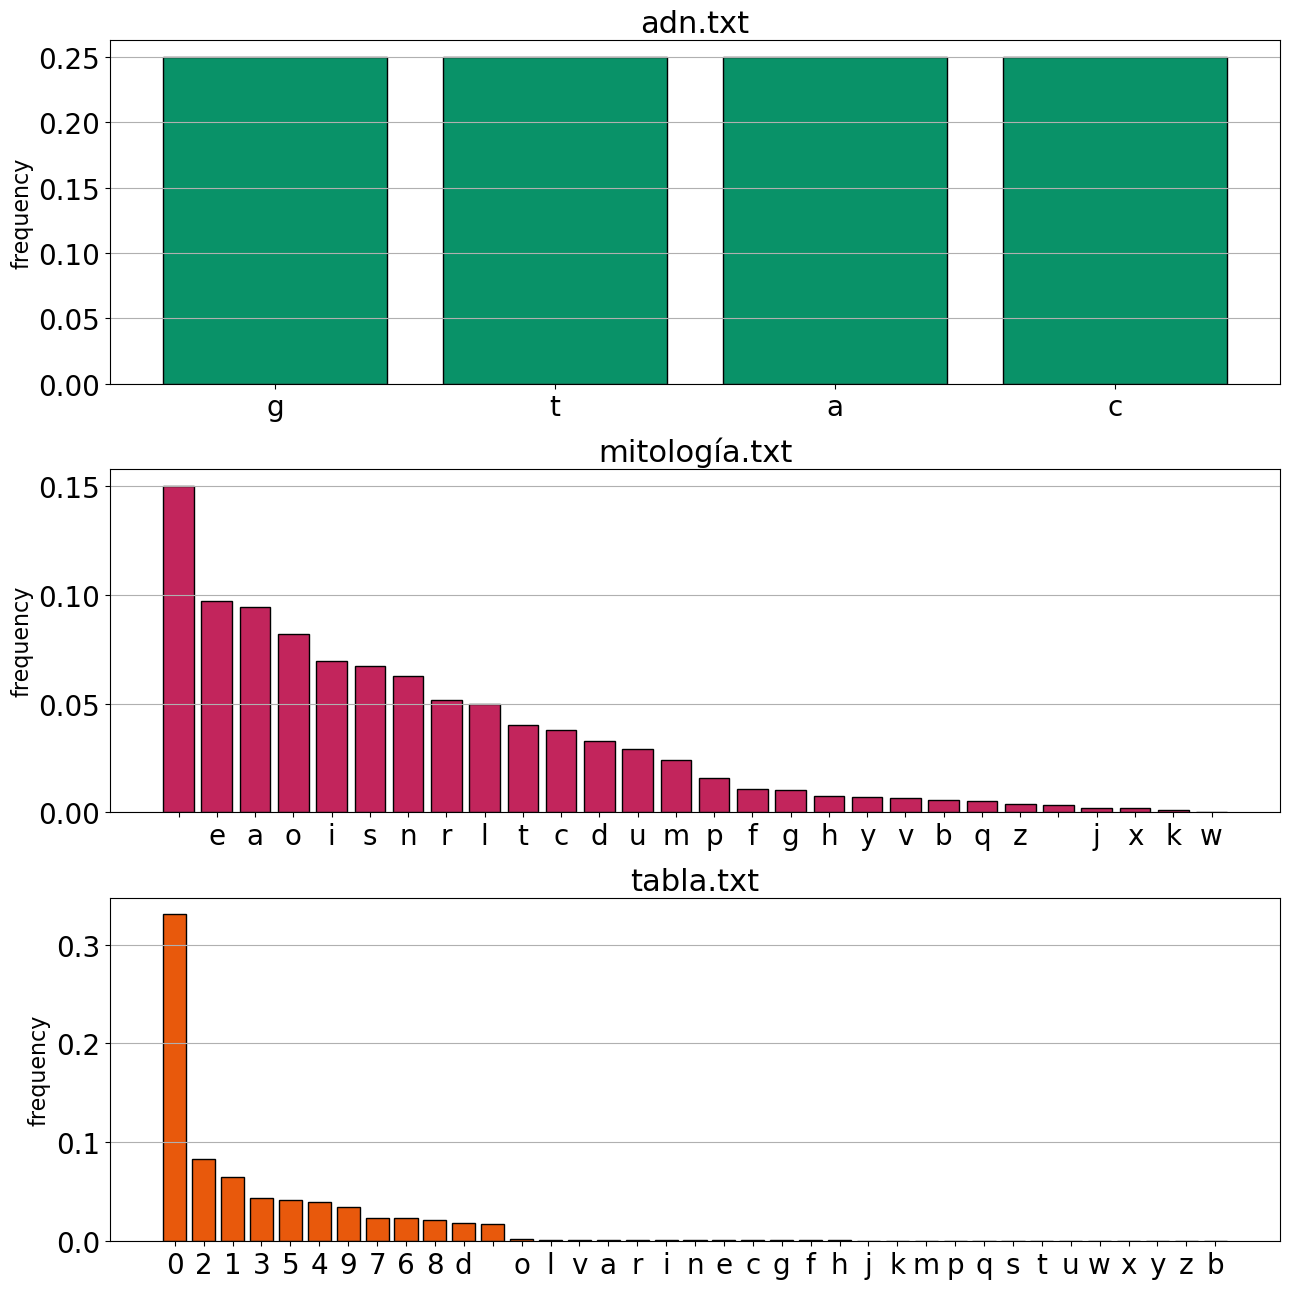

In [66]:
fig = plt.figure(figsize=(13,13))
idx = 311
colors = ['#e8590c', '#c2255c', '#099268']

for file, string in zip(example_strings_name, example_strings):
    pmf = character_pmf(string, True)
    pmf_chart(pmf, fig, idx, colors.pop(), file)
    idx += 1

plt.tight_layout()
plt.savefig(figures_path + 'character_strict_pmf.png')
plt.show()

---

### **EJERCICIO 2:** "Codificación" y Medidas de Rendimiento de Huffman

Utilizacion de **Algoritmo Huffman** provisto por la Catedra, Longitud Promedio, Comparacion de Cantidad de Bits con Codificacion Uniforme, y Reduccion de % en memoria.

---

In [58]:
def huffman_average_length(pmf: OrderedDict, huff_code: dict) -> float: 
	""" 
	
	"""

	return sum(prob * len(huff_code[char]) for char, prob in pmf.items())

def uniform_code_length(num_symbols: int) -> int: 
	""" 
	
	"""

	return int(np.ceil(np.log2(num_symbols)))

def memory_reduction(huffman_length: float, unif_length: float) -> float: 
	""" 
	
	"""

	return np.abs((1 - huffman_length / unif_length) * 100)

def huffman_metrics(texts: list[str], ignore: bool = False) -> dict: 
	""" 
	
	"""
	pmfs = [character_pmf(text, ignore) for text in texts]
	huffman_codes = [huffman_code(pmf) for pmf in pmfs]

	metrics = {
		'symbol_amount': [],
		'average_length': [],
		'uniform_length': [],
		'memory_reduction': []
	}

	for pmf, huff_code in zip(pmfs, huffman_codes):
		n_symbols = len(pmf)
		avg_len = huffman_average_length(pmf, huff_code)
		unif_len = uniform_code_length(n_symbols)
		reduction = memory_reduction(avg_len, unif_len)

		metrics['symbol_amount'].append(n_symbols)
		metrics['average_length'].append(avg_len)
		metrics['uniform_length'].append(unif_len)
		metrics['memory_reduction'].append(reduction)

	return metrics

---
### **EJERCICIO 3:** Entropia de Shannon

Calculo de la Entropia comprendida como la medida de incertidumbre de la fuente (texto).

$$
H(X) = -\sum_{i=1}^{N} p(x_i) \log_2 p(x_i)
$$

---

In [59]:
def entropy(prob: dict) -> float:
    """ 
    Calcula la entropia de Shannon de una distribucion de masa de probabilidad 
    
    Args:
        prob (OrderedDict[str, float]): diccionario ordenado en funcion de la frecuencia de aparicion {caracter : frecuencia}
    
    Returns:
        float: valor de la entropia de Shannon H(X)
    """

    output = 0
    
    for char in prob.keys():
        p = prob[char]
        output += p*np.log2(p)
    
    return -output        

--- 

### **EJERCICIO 4:** Entropia Normalizada

Calculo de Entropia Normalizada, la cual nos permite comparar entropias correspondientes de fuentes de distintos simbolos/caracteres, donde $N$ representa la cantidad de simbolos unicos:

$$
\eta = \frac{H(X)}{\log_2(N)}
$$

---

In [60]:
def norm_entropy(prob: dict) -> float:
    """

    Calcula la entropia normalizada de una distribucion de masa de probabilidad

    Args:
        prob (OrderedDict[str, float]): diccionario ordenado en funcion de la frecuencia de aparicion {caracter : frecuencia}

    Returns:
        float: valor de la entropia normalizada
    """
    
    return entropy(prob)/np.log2(len(list(prob.keys())))

In [61]:
def entropy_metrics(texts: list[str], ignore: bool = False) -> dict:
	"""
	Calcula entropia Shannon y Normalizada del ejercicio 3 y 4 para textos de ejemplo.

	Args:
		texts: lista de cadenas de texto a analizar

	Returns:
		dict: diccionario con listas de entropais
	"""
	pmfs = [character_pmf(text, ignore) for text in texts]
    
	metrics = {
		'entropy': [entropy(pmf) for pmf in pmfs],
		'norm_entropy': [norm_entropy(pmf) for pmf in pmfs]
	}

	return metrics

---

### **Cuadro comparativo**: Medidas de Desempeño

---

In [62]:
def get_dataframe(ignore: bool = False):
	huffman_metrics_dict = huffman_metrics(example_strings, ignore)
	entropy_metrics_dict = entropy_metrics(example_strings, ignore)

	# Organización de los datos
	labels = ['Archivo', 'Entropía', 'Entropía Normalizada', 'Cantidad de Símbolos', 'Longitud Promedio', 'Longitud Uniforme Mínima', 'Reducción de Memoria']
	data = [
			example_strings_name, 
			entropy_metrics_dict['entropy'], 
			entropy_metrics_dict['norm_entropy'], 
			huffman_metrics_dict['symbol_amount'], 
			huffman_metrics_dict['average_length'], 
			huffman_metrics_dict['uniform_length'], 
			huffman_metrics_dict['memory_reduction']
		]

	units = {
			"Entropía": "[bits/symbol]",
			"Entropía Normalizada": "[0..1]",
			"Cantidad de Símbolos": "[count]",
			"Longitud Promedio": "[bits/symbol]",
			"Longitud Uniforme Mínima": "[bits/symbol]",
			"Reducción de Memoria": "[%]"
	}
	# Creación del DataFrame
	df = pd.DataFrame()
	for label, collumn in zip(labels[::-1], data[::-1]):
		df.insert(0, label, collumn)
		
	# Agrega una fila en los índices para las unidades
	df.columns = pd.MultiIndex.from_tuples([(col, units.get(col, "")) for col in df.columns])

	# Formateo de la Tabla
	df = (
		df.style
			.format(precision=6)
			.set_caption('Resumen de Datos para los textos de ejemplo')
			.set_table_styles([
				{"selector": "caption",
				"props": [("font-size", "18pt"), ("font-weight", "bold"), ("text-align", "center"), ("padding", "6px")]},
				# head
				{"selector": "th.col_heading",
				"props": [("font-size", "15pt"), ("font-weight", "600"), ("text-align", "center")]},
				# unidades
				{"selector": "th.col_heading.level1",
				"props": [("font-size", "10pt"), ("font-weight", "400")]}, 
				# celdas
				{"selector": "td", 
				"props": [("font-size", "14pt"), ("text-align", "center")]},
			])
	)
	return df

#### Datos con **inclución** de mayúsculas, puntuaciones y diacríticos.

In [63]:
df = get_dataframe(False)
df

,Archivo,Entropía,Entropía Normalizada,Cantidad de Símbolos,Longitud Promedio,Longitud Uniforme Mínima,Reducción de Memoria
,,[bits/symbol],[0..1],[count],[bits/symbol],[bits/symbol],[%]
0,adn.txt,1.999999,1.000000,4,2.000000,2,0.000000
1,mitología.txt,4.268560,0.791600,42,4.301327,6,28.311223
2,tabla.txt,3.467726,0.647259,41,3.517295,6,41.378417


#### Datos con **exclución** de mayúsculas, puntuaciones y diacríticos.

In [64]:
df_ignored = get_dataframe(True)
df_ignored

,Archivo,Entropía,Entropía Normalizada,Cantidad de Símbolos,Longitud Promedio,Longitud Uniforme Mínima,Reducción de Memoria
,,[bits/symbol],[0..1],[count],[bits/symbol],[bits/symbol],[%]
0,adn.txt,1.999999,1.000000,4,2.000000,2,0.000000
1,mitología.txt,3.955781,0.822860,28,3.945041,5,21.099179
2,tabla.txt,2.650759,0.508836,37,2.391955,6,60.134085


(ignorar) tablas en formato latex para el informe

In [44]:
latex = df.to_latex()
print(latex)

\begin{table}
\caption{Resumen de Datos para los textos de ejemplo}
\th.col_heading15pt
\th.col_heading.level110pt
\td14pt
\begin{tabular}{llrrrrrr}
 & Archivo & Entropía & Entropía Normalizada & Cantidad de Símbolos & Longitud Promedio & Longitud Uniforme Mínima & Reducción de Memoria \\
 &  & [bits/symbol] & [0..1] & [count] & [bits/symbol] & [bits/symbol] & [%] \\
0 & adn.txt & 1.999999 & 1.000000 & 4 & 2.000000 & 2 & 0.000000 \\
1 & mitología.txt & 4.332977 & 0.736570 & 59 & 4.366182 & 6 & 27.230294 \\
2 & tabla.txt & 3.480857 & 0.610630 & 52 & 3.530120 & 6 & 41.164659 \\
\end{tabular}
\end{table}



In [45]:
latex_ignored = df_ignored.to_latex()
print(latex_ignored)

\begin{table}
\caption{Resumen de Datos para los textos de ejemplo}
\th.col_heading15pt
\th.col_heading.level110pt
\td14pt
\begin{tabular}{llrrrrrr}
 & Archivo & Entropía & Entropía Normalizada & Cantidad de Símbolos & Longitud Promedio & Longitud Uniforme Mínima & Reducción de Memoria \\
 &  & [bits/symbol] & [0..1] & [count] & [bits/symbol] & [bits/symbol] & [%] \\
0 & adn.txt & 1.999999 & 1.000000 & 4 & 2.000000 & 2 & 0.000000 \\
1 & mitología.txt & 3.517115 & 0.748252 & 26 & 3.302169 & 5 & 33.956622 \\
2 & tabla.txt & 2.546965 & 0.492650 & 36 & 2.265255 & 6 & 62.245757 \\
\end{tabular}
\end{table}

